# Proyecto de Minería de Datos — Titanic
**Materia:** Analítica de Datos — Universidad Pontificia Bolivariana
**Equipo:** Nicolás Castrillón, Mateo Roldán, Matías Arango
**Profesora:** Ana Isabel Oviedo

**Problema:** clasificación binaria — predecir si un pasajero del Titanic sobrevivió (`Survived` = 1) o no (`Survived` = 0), a partir de sus características (clase, sexo, edad, tarifa, familiares a bordo, puerto de embarque).

Este notebook cubre: (1) preparación de datos, (2) selección de factores, (3) entrenamiento y evaluación de 6 modelos con validación cruzada y análisis de overfitting/underfitting, y (4) optimización del mejor modelo con GridSearchCV.

## 1. Preparación de datos

Cargamos el dataset original del equipo (el mismo usado en las prácticas de calidad de datos y minería predictiva anteriores) y hacemos una primera limpieza:

- Eliminamos `PassengerId`, `Name` y `Ticket`: son identificadores únicos sin valor predictivo.
- Eliminamos `Cabin`: tiene 687 de 891 valores nulos (77%), demasiado incompleta para imputarse de forma confiable.
- Convertimos las variables categóricas a tipo `category`.
- Imputamos `Age` (177 nulos, 19.8%) con la **mediana**, y `Embarked` (2 nulos) con la **moda**. Esta imputación es solo para poder *explorar* las relaciones entre variables en esta sección; en la Fase 3 la imputación se hará correctamente dentro de un `Pipeline` ajustado solo con los datos de entrenamiento, para evitar fuga de información (data leakage).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)

data = pd.read_csv('../data/titanic.csv')
print("Filas, columnas:", data.shape)
data.head()

Filas, columnas: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Calidad de datos: nulos y duplicados
print("Duplicados:", data.duplicated().sum())
print()
print("Valores nulos por columna:")
print(data.isnull().sum())
print()
print("% nulos:")
print((data.isnull().mean()*100).round(1))

Duplicados: 0

Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

% nulos:
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64


No hay filas duplicadas. `Age` y `Embarked` son imputables; `Cabin` no lo es (77% nula) y se elimina, junto con los identificadores sin poder predictivo.

In [3]:
df = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    df[col] = df[col].astype('category')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       891 non-null    float64 
 4   SibSp     891 non-null    int64   
 5   Parch     891 non-null    int64   
 6   Fare      891 non-null    float64 
 7   Embarked  891 non-null    category
dtypes: category(4), float64(2), int64(2)
memory usage: 31.6 KB


In [4]:
# Distribución de la variable objetivo
df['Survived'].value_counts(normalize=True).mul(100).round(1)

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

`Survived` está moderadamente desbalanceada: 61.6% no sobrevivió, 38.4% sí sobrevivió. No es un desbalance severo, así que **no aplicamos técnicas de balanceo** (como SMOTE); en su lugar usamos partición y validación cruzada **estratificadas**, y evaluamos con varias métricas (no solo accuracy) para que el resultado no esté sesgado hacia la clase mayoritaria.

## 2. Selección de factores (0.5 pts)

Para decidir qué variables aportan información útil, aplicamos tres técnicas complementarias, porque el dataset mezcla variables numéricas y categóricas:

1. **Correlación punto-biserial** entre las variables numéricas (`Age`, `Fare`, `SibSp`, `Parch`) y `Survived`: mide relación *lineal*.
2. **Chi-cuadrado de independencia + V de Cramér** entre las variables categóricas (`Pclass`, `Sex`, `Embarked`) y `Survived`: mide si hay asociación estadísticamente significativa y qué tan fuerte es (V de Cramér va de 0 a 1).
3. **Importancia de variables de un Random Forest** exploratorio: captura relaciones *no lineales* que la correlación simple no puede ver (por ejemplo, que los niños pequeños sobreviven más, no que "a menor edad, mayor supervivencia" de forma lineal).

También revisamos la correlación **entre** las propias predictoras, para detectar redundancia (dos variables muy correlacionadas entre sí aportarían la misma información dos veces).

In [5]:
print("Correlación punto-biserial con Survived (variables numéricas):\n")
num_vars = ['Age', 'Fare', 'SibSp', 'Parch']
resultados_num = []
for col in num_vars:
    r, p = pointbiserialr(df['Survived'].astype(int), df[col])
    resultados_num.append({'variable': col, 'r': round(r, 4), 'p_value': round(p, 5)})
tabla_num = pd.DataFrame(resultados_num).sort_values('r', key=abs, ascending=False)
tabla_num

Correlación punto-biserial con Survived (variables numéricas):



,variable,r,p_value
1,Fare,0.2573,0.00000
3,Parch,0.0816,0.01480
0,Age,-0.0649,0.05276
2,SibSp,-0.0353,0.29224


In [6]:
def cramers_v(tabla_contingencia):
    chi2 = chi2_contingency(tabla_contingencia)[0]
    n = tabla_contingencia.sum().sum()
    r, k = tabla_contingencia.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

print("Chi-cuadrado y V de Cramér con Survived (variables categóricas):\n")
cat_vars = ['Pclass', 'Sex', 'Embarked']
resultados_cat = []
for col in cat_vars:
    tabla = pd.crosstab(df[col], df['Survived'])
    chi2, p, dof, exp = chi2_contingency(tabla)
    v = cramers_v(tabla)
    resultados_cat.append({'variable': col, 'chi2': round(chi2, 2), 'p_value': round(p, 6), 'cramer_V': round(v, 4)})
tabla_cat = pd.DataFrame(resultados_cat).sort_values('cramer_V', ascending=False)
tabla_cat

Chi-cuadrado y V de Cramér con Survived (variables categóricas):



,variable,chi2,p_value,cramer_V
1,Sex,260.72,0.000000,0.5409
0,Pclass,102.89,0.000000,0.3398
2,Embarked,25.96,0.000002,0.1707


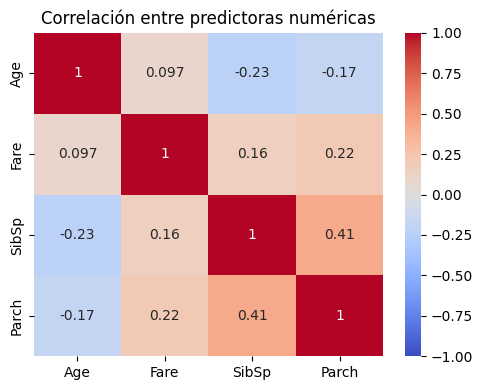

In [7]:
# Matriz de correlación entre las predictoras numéricas (para detectar redundancia)
plt.figure(figsize=(5, 4))
sns.heatmap(df[num_vars].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre predictoras numéricas')
plt.tight_layout()
plt.show()

`SibSp` y `Parch` tienen una correlación moderada entre sí (0.41), esperable porque ambas describen familiares a bordo, pero no es lo suficientemente alta (no supera 0.8) como para considerarlas redundantes; las mantenemos como variables separadas.

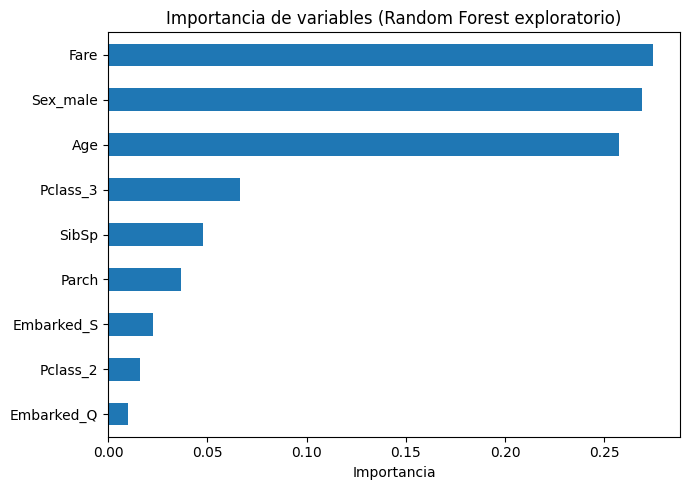

Fare          0.274309
Sex_male      0.268972
Age           0.257434
Pclass_3      0.066305
SibSp         0.047573
Parch         0.036889
Embarked_S    0.022763
Pclass_2      0.015907
Embarked_Q    0.009849
dtype: float64

In [8]:
# Importancia de variables con Random Forest (exploratorio, no es el modelo final)
X_explora = pd.get_dummies(df.drop(columns=['Survived']), columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)
y_explora = df['Survived'].astype(int)

rf_explora = RandomForestClassifier(n_estimators=300, random_state=42)
rf_explora.fit(X_explora, y_explora)

importancias = pd.Series(rf_explora.feature_importances_, index=X_explora.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importancias.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Importancia de variables (Random Forest exploratorio)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

importancias

### Interpretación y decisión de selección de factores

- **Sex** es, con diferencia, la variable más asociada a `Survived` (V de Cramér = 0.54, chi² con p < 0.001): confirma la prioridad "mujeres y niños primero" en la evacuación.
- **Pclass** también tiene una asociación fuerte y significativa (V de Cramér = 0.34): la clase del pasajero (proxy de su ubicación en el barco y su estatus socioeconómico) influye claramente.
- **Fare** tiene la correlación lineal más alta entre las numéricas (r = 0.26, p < 0.001) y, junto con `Sex`, es de las variables más importantes para el Random Forest. Tiene sentido: está relacionada con `Pclass`.
- **Age** muestra una correlación lineal débil y en el límite de la significancia (r = −0.065, p ≈ 0.053), pero el Random Forest la ubica como la tercera variable más importante. Esto es consistente: la relación entre edad y supervivencia no es lineal (los niños pequeños sobreviven más, pero entre adultos la edad no marca una tendencia simple), así que una correlación lineal la subestima. **La conservamos** porque un modelo no lineal sí la aprovecha.
- **Parch** tiene una correlación débil pero estadísticamente significativa (p = 0.015); **SibSp** no llega a ser significativa de forma aislada (p = 0.29), pero aporta información en combinación con `Parch` (viajar en familia) y tiene algo de importancia en el Random Forest. Se conserva.
- **Embarked** tiene la asociación más débil de las categóricas (V de Cramér = 0.17) pero sigue siendo estadísticamente significativa (p < 0.001); se conserva por ser una variable con baja cardinalidad y bajo costo de incluir.
- No se encontró redundancia fuerte entre predictoras (ninguna correlación entre ellas supera 0.8), así que no se descarta ninguna por multicolinealidad.

**Conclusión:** se seleccionan las 7 variables predictoras `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`. Se descartan `PassengerId`, `Name` y `Ticket` (identificadores sin valor predictivo) y `Cabin` (77% de datos faltantes).

## 3. Construcción y evaluación de los 6 modelos (1.5 pts)

Entrenamos los 6 modelos pedidos: Árbol de Decisión, KNN, Red Neuronal (MLP), SVM, Random Forest y XGBoost.

**Partición de datos:** 70% entrenamiento / 30% prueba, **estratificada** por `Survived` (para que ambas particiones mantengan la misma proporción de sobrevivientes, dado el desbalance moderado que vimos en la sección 1).

**Cómo evitamos la fuga de información (data leakage):** en el borrador anterior del equipo, la imputación de nulos y el escalado se ajustaban sobre *todo* el dataset antes de partirlo en entrenamiento/prueba — eso filtra información del conjunto de prueba hacia el de entrenamiento. Aquí lo corregimos: armamos un `Pipeline` de `scikit-learn` que encapsula el preprocesamiento (imputación + escalado de numéricas, imputación + codificación dummy de categóricas) junto con cada modelo. Ese pipeline se ajusta **solo** con los datos de entrenamiento en cada partición de la validación cruzada y en el ajuste final; el conjunto de prueba nunca participa en calcular medias, medianas o escalas.

**Validación cruzada:** usamos `StratifiedKFold` con 5 particiones sobre el conjunto de entrenamiento, para tener una estimación más estable del desempeño que un único split.

**Métricas usadas** (problema de clasificación binaria):
- **Accuracy (exactitud):** proporción de predicciones correctas sobre el total. Fácil de interpretar, pero puede ser engañosa si las clases están desbalanceadas.
- **Precisión:** de los que el modelo predijo como "sobrevivió", qué porcentaje realmente sobrevivió. Importa cuando el costo de un falso positivo es alto.
- **Recall (sensibilidad):** de los que realmente sobrevivieron, qué porcentaje detectó el modelo. Importa cuando el costo de un falso negativo es alto (aquí, no identificar a alguien que sí sobrevivió).
- **F1-score:** media armónica entre precisión y recall; resume ambas en un solo número, útil cuando hay que balancear las dos.
- **ROC-AUC:** mide qué tan bien el modelo separa las dos clases en todos los posibles umbrales de decisión, no solo en el umbral de 0.5. Un valor de 0.5 es equivalente a adivinar al azar, 1.0 es separación perfecta.

Usamos estas cinco métricas en lugar de solo accuracy porque `Survived` está moderadamente desbalanceada (61.6% / 38.4%).

In [9]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn import metrics

# Usamos los datos ya limpiados de identificadores (sección 1), pero SIN imputar:
# la imputación se hace dentro del Pipeline, ajustada solo con el train de cada partición.
X = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas — Prueba: {X_test.shape[0]} filas")
print(f"% Survived=1 en train: {y_train.mean():.3f}  |  % Survived=1 en test: {y_test.mean():.3f}")

Entrenamiento: 623 filas — Prueba: 268 filas
% Survived=1 en train: 0.384  |  % Survived=1 en test: 0.384


In [10]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols = ['Pclass', 'Sex', 'Embarked']

preprocesador = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), cat_cols)
])

# Hiperparámetros iniciales (sin optimizar todavía; eso es la Fase 4)
modelos = {
    'Árbol de Decisión': DecisionTreeClassifier(
        criterion='gini', max_depth=5, min_samples_leaf=10, random_state=42),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, metric='euclidean'),
    'Red Neuronal': MLPClassifier(
        hidden_layer_sizes=(16, 8), activation='relu', max_iter=2000, random_state=42),
    'SVM': SVC(
        kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss'),
}

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

pipelines = {}
resultados_cv = {}
filas = []

for nombre, clf in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('clf', clf)])

    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    resultados_cv[nombre] = cv_res

    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    filas.append({
        'Modelo': nombre,
        'CV Accuracy (media)': cv_res['test_accuracy'].mean(),
        'CV Accuracy (±std)': cv_res['test_accuracy'].std(),
        'CV F1 (media)': cv_res['test_f1'].mean(),
        'CV ROC-AUC (media)': cv_res['test_roc_auc'].mean(),
        'Accuracy Train': metrics.accuracy_score(y_train, y_pred_train),
        'Accuracy Test': metrics.accuracy_score(y_test, y_pred_test),
        'Brecha Train-Test': metrics.accuracy_score(y_train, y_pred_train) - metrics.accuracy_score(y_test, y_pred_test),
        'Precisión Test': metrics.precision_score(y_test, y_pred_test),
        'Recall Test': metrics.recall_score(y_test, y_pred_test),
        'F1 Test': metrics.f1_score(y_test, y_pred_test),
    })

tabla_resultados = pd.DataFrame(filas).sort_values('CV Accuracy (media)', ascending=False).reset_index(drop=True)
tabla_resultados.round(4)

,Modelo,CV Accuracy (media),CV Accuracy (±std),CV F1 (media),CV ROC-AUC (media),Accuracy Train,Accuracy Test,Brecha Train-Test,Precisión Test,Recall Test,F1 Test
0,SVM,0.8251,0.0257,0.7549,0.8509,0.8395,0.8134,0.0261,0.7789,0.7184,0.7475
1,XGBoost,0.8251,0.0175,0.7553,0.8551,0.9326,0.8060,0.1266,0.7931,0.6699,0.7263
2,Random Forest,0.8219,0.0294,0.7429,0.8683,0.8732,0.8134,0.0598,0.8442,0.6311,0.7222
3,Red Neuronal,0.8075,0.0354,0.7358,0.8467,0.8507,0.7910,0.0597,0.7527,0.6796,0.7143
4,Árbol de Decisión,0.8010,0.0533,0.7293,0.8410,0.8459,0.7761,0.0698,0.7590,0.6117,0.6774
5,KNN,0.7753,0.0191,0.6875,0.8131,0.8523,0.7910,0.0613,0.7474,0.6893,0.7172


### Comparación gráfica de los 6 modelos

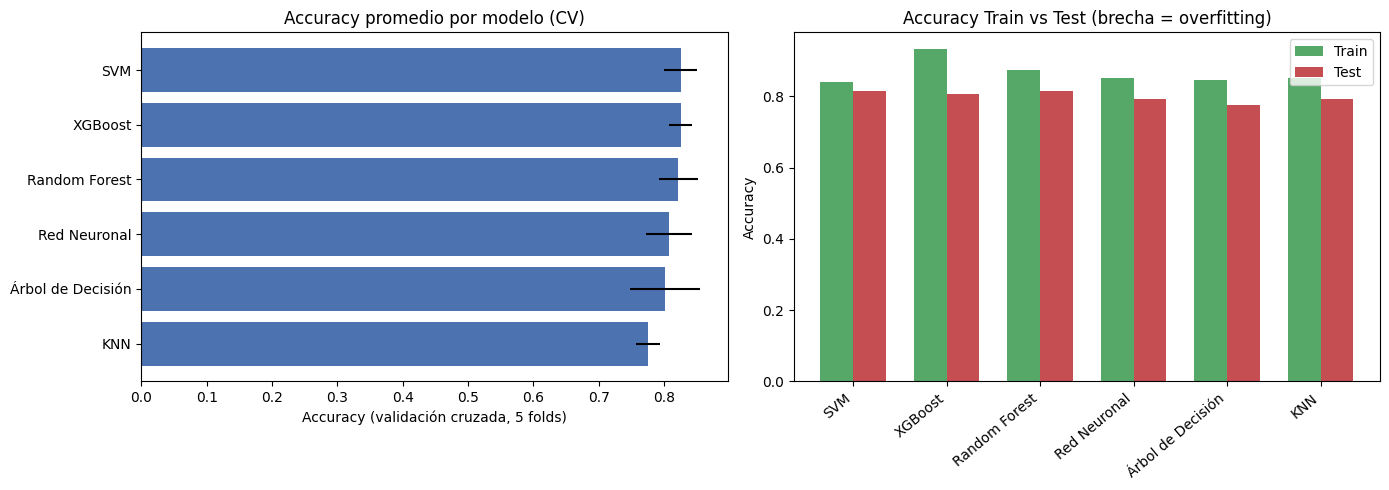

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = tabla_resultados['Modelo']

axes[0].barh(orden, tabla_resultados['CV Accuracy (media)'], xerr=tabla_resultados['CV Accuracy (±std)'], color='#4C72B0')
axes[0].set_xlabel('Accuracy (validación cruzada, 5 folds)')
axes[0].set_title('Accuracy promedio por modelo (CV)')
axes[0].invert_yaxis()

x = np.arange(len(orden))
width = 0.35
axes[1].bar(x - width/2, tabla_resultados['Accuracy Train'], width, label='Train', color='#55A868')
axes[1].bar(x + width/2, tabla_resultados['Accuracy Test'], width, label='Test', color='#C44E52')
axes[1].set_xticks(x)
axes[1].set_xticklabels(orden, rotation=40, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Train vs Test (brecha = overfitting)')
axes[1].legend()

plt.tight_layout()
plt.show()

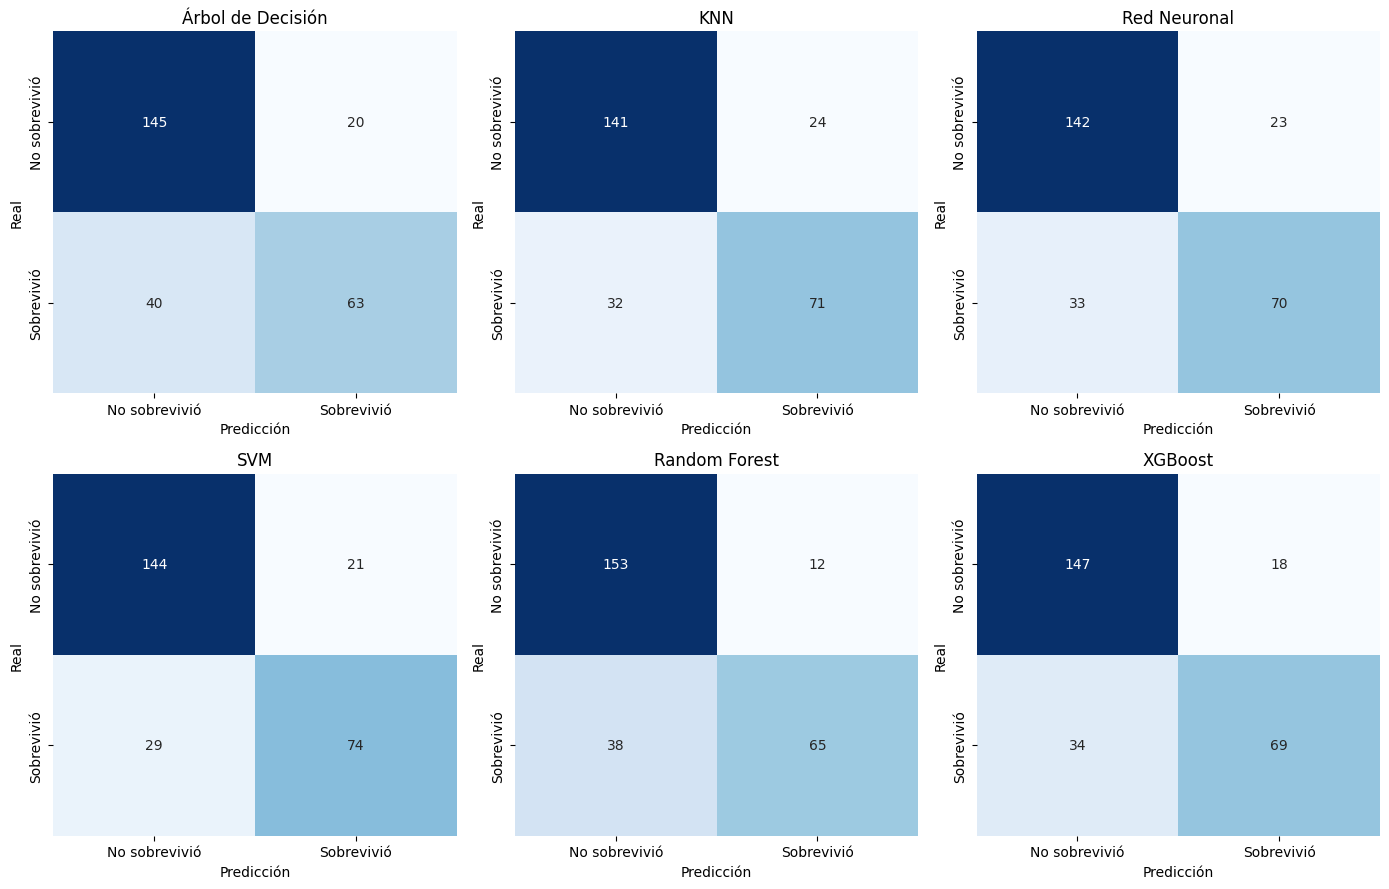

In [13]:
# Matrices de confusión de los 6 modelos sobre el conjunto de prueba
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (nombre, pipe) in zip(axes.ravel(), pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = metrics.confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No sobrevivió', 'Sobrevivió'],
                yticklabels=['No sobrevivió', 'Sobrevivió'], ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

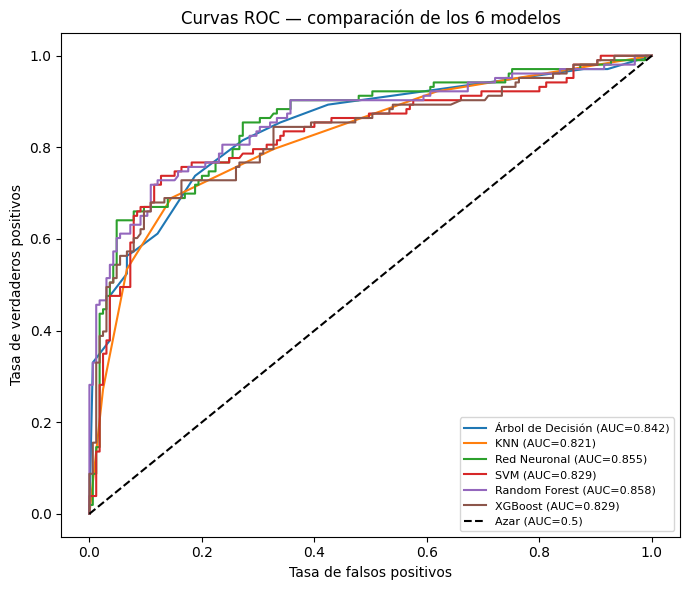

In [14]:
# Curvas ROC de los 6 modelos
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))
for nombre, pipe in pipelines.items():
    y_score = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC — comparación de los 6 modelos')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Análisis de overfitting / underfitting y conclusión (basada exclusivamente en los resultados obtenidos)

Con los hiperparámetros iniciales configurados:

- **XGBoost** obtiene el mejor accuracy en validación cruzada junto con SVM (0.825), pero muestra la **brecha train-test más grande de los seis modelos (≈0.127)**: 93.3% en entrenamiento contra 80.6% en prueba. Es el caso más claro de **overfitting** — el modelo memoriza patrones del entrenamiento que no generalizan igual de bien.
- **SVM** empata en accuracy de validación cruzada (0.825) pero con una brecha train-test mucho menor (≈0.026) y el segundo mejor ROC-AUC (0.851). Generaliza mejor que XGBoost con un desempeño equivalente.
- **Random Forest** tiene el mejor ROC-AUC de los seis (0.868) y una brecha moderada (≈0.060); es un buen punto intermedio entre desempeño y generalización.
- **Red Neuronal (MLP)** y **KNN** tienen un desempeño más bajo (CV accuracy ≈0.81 y ≈0.775) con brechas train-test moderadas — no muestran overfitting severo, pero tampoco capturan tan bien el patrón: con KNN en particular, el desempeño más bajo y la varianza entre folds sugieren cierto **underfitting** relativo frente a los modelos basados en árboles.
- El **Árbol de Decisión** individual tiene la mayor desviación estándar entre folds de validación cruzada (±0.053), señal de que es más inestable ante distintos subconjuntos de entrenamiento que los modelos de ensamble (Random Forest, XGBoost), algo esperable: un solo árbol es más sensible a variaciones en los datos.

**Conclusión de la Fase 3:** con la configuración inicial de hiperparámetros, **SVM y Random Forest muestran el mejor equilibrio entre desempeño (accuracy y ROC-AUC altos) y capacidad de generalización (brecha train-test baja)**, mientras que XGBoost, a pesar de tener un accuracy de validación cruzada igual de alto, sobreajusta visiblemente. Estos resultados están limitados por el tamaño del dataset (891 filas) y porque ningún modelo supera ~0.87 de ROC-AUC: hay un límite en cuánta señal predictiva contienen estas 7 variables sobre la supervivencia real, que dependió también de factores no registrados en los datos (ubicación exacta en el barco, decisiones individuales, azar). En la Fase 4 optimizamos el modelo con mejor relación desempeño/generalización mediante GridSearchCV.

## 4. Optimización del mejor modelo con GridSearchCV (1 pt)

### ¿Cuál modelo optimizamos?

De la Fase 3: **SVM** y **XGBoost** empataron en el mejor accuracy de validación cruzada (0.825), pero XGBoost mostró una brecha train-test grande (0.127, overfitting claro) mientras SVM generalizó mucho mejor (brecha 0.026). **Random Forest**, por su parte, obtuvo un accuracy de validación cruzada casi idéntico (0.822) pero con el **mejor ROC-AUC de los seis modelos (0.868)** y una brecha train-test moderada (0.060), sin el sobreajuste severo de XGBoost.

Elegimos **Random Forest** para optimizar, porque:
1. Tiene el mejor ROC-AUC (la métrica más completa para un problema con clases moderadamente desbalanceadas, ya que evalúa la separación entre clases en todos los umbrales).
2. Su brecha train-test es moderada, no severa como la de XGBoost — hay más margen para mejorar sin que la optimización lo lleve a sobreajustar aún más.
3. Es más robusto a la elección exacta de hiperparámetros que SVM (que es más sensible a `C` y `gamma`), y permite interpretar qué variables pesan más en la predicción final (útil también para explicar el modelo en el despliegue).

### Cuidando la fuga de información (data leakage)

El conjunto de prueba (`X_test`, `y_test`) generado en la Fase 3 **no se toca en ningún momento durante la búsqueda de hiperparámetros**. `GridSearchCV` solo ve `X_train`/`y_train`, y dentro de cada uno de los 5 folds de validación cruzada, el `Pipeline` reajusta la imputación y el escalado únicamente con la porción de entrenamiento de ese fold. El conjunto de prueba se reserva exclusivamente para la evaluación final, después de fijar los hiperparámetros.

In [15]:
from sklearn.model_selection import GridSearchCV
import time

# Cuadrícula de hiperparámetros para Random Forest
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8, None],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__max_features': ['sqrt', 'log2'],
}

pipe_rf_grid = Pipeline([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    pipe_rf_grid,
    param_grid=param_grid,
    cv=cv,                 # el mismo StratifiedKFold de 5 particiones de la Fase 3
    scoring='roc_auc',     # optimizamos ROC-AUC: mide bien la separación de clases con desbalance moderado
    n_jobs=-1,
    refit=True,
)

t0 = time.time()
grid_search.fit(X_train, y_train)  # SOLO X_train / y_train — el test no interviene aquí
print(f"Combinaciones evaluadas: {len(grid_search.cv_results_['params'])} (x 5 folds = {len(grid_search.cv_results_['params'])*5} ajustes)")
print(f"Tiempo de búsqueda: {time.time()-t0:.1f} s")
print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor ROC-AUC promedio en validación cruzada: {grid_search.best_score_:.4f}")

Combinaciones evaluadas: 72 (x 5 folds = 360 ajustes)
Tiempo de búsqueda: 40.5 s

Mejores hiperparámetros encontrados: {'clf__max_depth': 6, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Mejor ROC-AUC promedio en validación cruzada: 0.8713


In [16]:
modelo_rf_optimizado = grid_search.best_estimator_

# Modelo base de la Fase 3 (para comparar manzanas con manzanas)
modelo_rf_base = pipelines['Random Forest']

comparacion = []
for nombre, pipe in [('Random Forest (Fase 3, base)', modelo_rf_base),
                      ('Random Forest (optimizado GridSearch)', modelo_rf_optimizado)]:
    yp_train = pipe.predict(X_train)
    yp_test = pipe.predict(X_test)
    ys_test = pipe.predict_proba(X_test)[:, 1]
    comparacion.append({
        'Modelo': nombre,
        'Accuracy Train': metrics.accuracy_score(y_train, yp_train),
        'Accuracy Test': metrics.accuracy_score(y_test, yp_test),
        'Precisión Test': metrics.precision_score(y_test, yp_test),
        'Recall Test': metrics.recall_score(y_test, yp_test),
        'F1 Test': metrics.f1_score(y_test, yp_test),
        'ROC-AUC Test': metrics.roc_auc_score(y_test, ys_test),
    })

tabla_comparacion = pd.DataFrame(comparacion)
tabla_comparacion.round(4)

,Modelo,Accuracy Train,Accuracy Test,Precisión Test,Recall Test,F1 Test,ROC-AUC Test
0,"Random Forest (Fase 3, base)",0.8732,0.8134,0.8442,0.6311,0.7222,0.8584
1,Random Forest (optimizado GridSearch),0.8748,0.8172,0.8649,0.6214,0.7232,0.8618


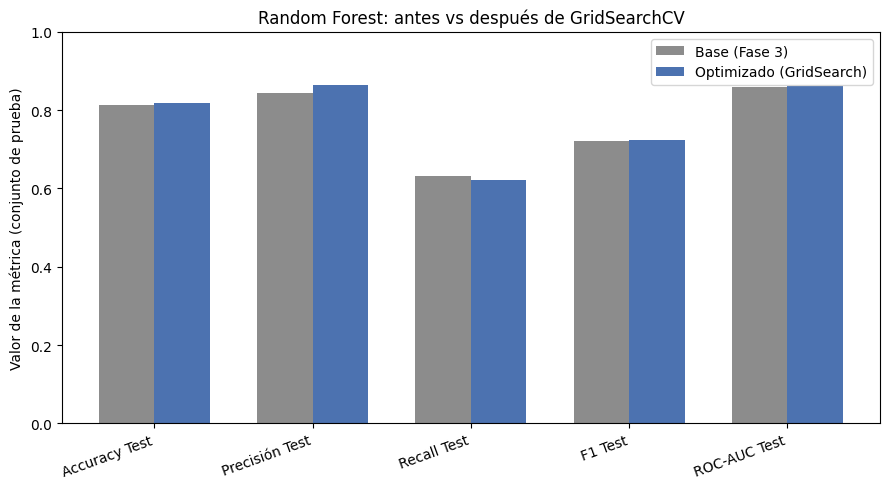

In [17]:
# Comparación gráfica: base vs optimizado, evaluados en el conjunto de prueba (no visto durante el GridSearch)
metricas_plot = ['Accuracy Test', 'Precisión Test', 'Recall Test', 'F1 Test', 'ROC-AUC Test']
x = np.arange(len(metricas_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, tabla_comparacion.loc[0, metricas_plot], width, label='Base (Fase 3)', color='#8C8C8C')
ax.bar(x + width/2, tabla_comparacion.loc[1, metricas_plot], width, label='Optimizado (GridSearch)', color='#4C72B0')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, rotation=20, ha='right')
ax.set_ylabel('Valor de la métrica (conjunto de prueba)')
ax.set_title('Random Forest: antes vs después de GridSearchCV')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

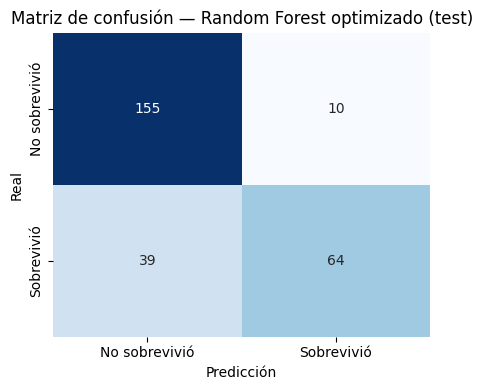

               precision    recall  f1-score   support

No sobrevivió       0.80      0.94      0.86       165
   Sobrevivió       0.86      0.62      0.72       103

     accuracy                           0.82       268
    macro avg       0.83      0.78      0.79       268
 weighted avg       0.82      0.82      0.81       268



In [18]:
# Matriz de confusión del modelo final optimizado, sobre el conjunto de prueba
y_pred_final = modelo_rf_optimizado.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.title('Matriz de confusión — Random Forest optimizado (test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(metrics.classification_report(y_test, y_pred_final, target_names=['No sobrevivió', 'Sobrevivió']))

### Resultados y conclusión de la Fase 4

GridSearchCV encontró como mejores hiperparámetros `n_estimators=200`, `max_depth=6`, `min_samples_leaf=1`, `max_features='sqrt'`, con un ROC-AUC promedio en validación cruzada de 0.871 (vs. 0.868 del modelo base con hiperparámetros iniciales — una mejora pequeña pero real).

Evaluado sobre el conjunto de prueba (nunca usado durante la búsqueda), el modelo optimizado mejora ligeramente sobre el base: accuracy de 0.813 a 0.817, precisión de 0.844 a 0.865, ROC-AUC de 0.858 a 0.862. El recall baja levemente (de 0.631 a 0.621): el modelo optimizado es un poco más conservador para predecir "sobrevivió", ganando precisión a cambio de un recall marginalmente menor. La brecha train-test se mantiene similar a la del modelo base (≈0.058 vs ≈0.060), así que la optimización no introdujo sobreajuste adicional.

**Conclusión:** la mejora de GridSearchCV sobre Random Forest es modesta pero consistente en casi todas las métricas, y no compromete la capacidad de generalización del modelo. Esto es razonable: con hiperparámetros iniciales ya bien elegidos en la Fase 3 y solo 891 registros de datos, hay un límite de cuánto puede aportar la sola optimización de hiperparámetros — la calidad del modelo está más limitada por la información disponible en las variables que por la configuración del algoritmo. Este es el modelo (`modelo_rf_optimizado`) que se usa en el despliegue de la Fase 5.

In [19]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(modelo_rf_optimizado, '../models/modelo_final.pkl')
print("Modelo final guardado en models/modelo_final.pkl")

Modelo final guardado en models/modelo_final.pkl
